<a href="https://colab.research.google.com/github/prksh830/Healthcare/blob/main/WSN_EE(Abiconf).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
# Load dataset
df = pd.read_csv("WSN_Dataset.csv")

# Quick inspection
print(df.shape)
print(df.head())
print(df.info())

(1000, 18)
  node_id cluster_id  residual_energy  initial_energy  proximity_to_CH  \
0      N1         C3             1.63            2.20            16.72   
1      N2         C4             1.51            2.04            15.53   
2      N3         C1             1.69            1.81            11.90   
3      N4         C3             1.90            2.31            19.16   
4      N5         C3             1.74            2.18             4.81   

   authentication_success  authentication_latency  key_exchange_time  \
0                       1                   53.47              34.36   
1                       1                   75.12              25.17   
2                       1                   31.60              29.60   
3                       0                   49.68              28.50   
4                       1                   56.41              24.97   

   total_energy_used          role  rekey_interval  compromised_status  \
0               0.57  Cluster Head   

In [ ]:
# Avoid division by zero
df['energy_efficiency'] = df['residual_energy'] / (df['initial_energy'] + 1e-6)
df['packet_success_ratio'] = df['data_packets_received'] / (df['data_packets_sent'] + 1e-6)
df['security_score'] = df['authentication_success'] * (1 - df['compromised_status'])

In [ ]:
# Label Encoding
le_role = LabelEncoder()
df['role'] = le_role.fit_transform(df['role'])

# cluster_id can be treated as categorical
le_cluster = LabelEncoder()
df['cluster_id'] = le_cluster.fit_transform(df['cluster_id'])

In [ ]:
X = df.drop(columns=['secure_and_efficient', 'node_id'])
y = df['secure_and_efficient']

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)

(700, 19) (150, 19) (150, 19)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
class AttentionLayer(layers.Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], input_shape[-1]),
                                 initializer='random_normal',
                                 trainable=True)
        self.b = self.add_weight(shape=(input_shape[-1],),
                                 initializer='zeros',
                                 trainable=True)

    def call(self, inputs):
        score = tf.nn.tanh(tf.matmul(inputs, self.W) + self.b)
        attention_weights = tf.nn.softmax(score, axis=1)
        context = attention_weights * inputs
        return context

In [ ]:
def build_model(input_dim):
    inputs = layers.Input(shape=(input_dim,))

    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # Attention Layer
    x = AttentionLayer()(x)

    # Residual Block
    shortcut = x
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(256)(x)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, activation='relu')(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)

    return model

In [ ]:
model = build_model(X_train.shape[1])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      2,560 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     33,024 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 256)       │     65,792 │ batch_normalizat… │
│ (AttentionLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │     65,792 │ attention_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     65,792 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense_3[0][0],    │
│                     │                   │            │ attention_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256)       │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │        129 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 267,521 (1.02 MB)

 Trainable params: 266,753 (1.02 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
early_stop = EarlyStopping(patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(factor=0.3, patience=5)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.6986 - loss: 0.6307 - val_accuracy: 0.7067 - val_loss: 0.5748 - learning_rate: 0.0010
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8257 - loss: 0.3997 - val_accuracy: 0.8733 - val_loss: 0.3521 - learning_rate: 0.0010
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9100 - loss: 0.2386 - val_accuracy: 0.9600 - val_loss: 0.2513 - learning_rate: 0.0010
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9214 - loss: 0.1845 - val_accuracy: 0.8800 - val_loss: 0.2365 - learning_rate: 0.0010
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9457 - loss: 0.1235 - val_accuracy: 0.8933 - val_loss: 0.2534 - learning_rate: 0.0010
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9414 - loss: 0.1347 - val_accuracy: 0.9200 - val_loss: 0.2000 - learning_rate: 0.0010
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9371 - loss: 0.1327 - 

In [ ]:
# Predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Metrics
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ROC-AUC
auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC Score:", auc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        44
           1       0.98      1.00      0.99       106

    accuracy                           0.99       150
   macro avg       0.99      0.98      0.98       150
weighted avg       0.99      0.99      0.99       150

Confusion Matrix:
 [[ 42   2]
 [  0 106]]
ROC-AUC Score: 0.9995711835334478


In [ ]:
model.save("wsn_attention_model.h5")

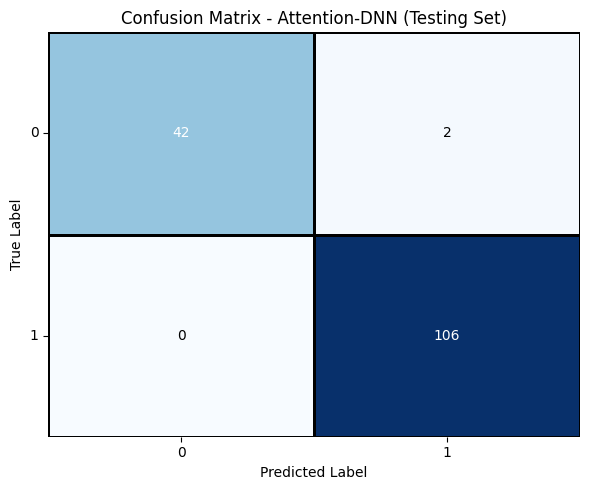

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

# Custom color map
cmap = sns.color_palette(["#87CEEB", "#0B3C5D"])  # sky blue & dark blue

# Normalize for better visualization (optional)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", cbar=False,
            linewidths=1, linecolor='black')

# Manually adjust text color
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text = plt.gca().texts[i*cm.shape[1] + j]
        if i == j:
            text.set_color("white")   # diagonal
        else:
            text.set_color("black")   # off-diagonal

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Attention-DNN (Testing Set)")
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

In [15]:
# Evaluate on training set
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Training Accuracy:", train_acc)
print("Training Loss:", train_loss)

print("Testing Accuracy:", test_acc)
print("Testing Loss:", test_loss)

Training Accuracy: 0.9985714554786682
Training Loss: 0.008566463366150856
Testing Accuracy: 0.9866666793823242
Testing Loss: 0.03328731656074524


In [16]:
# Training predictions
y_train_prob = model.predict(X_train)
y_train_pred = (y_train_prob > 0.5).astype(int)

# Testing predictions
y_test_prob = model.predict(X_test)
y_test_pred = (y_test_prob > 0.5).astype(int)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


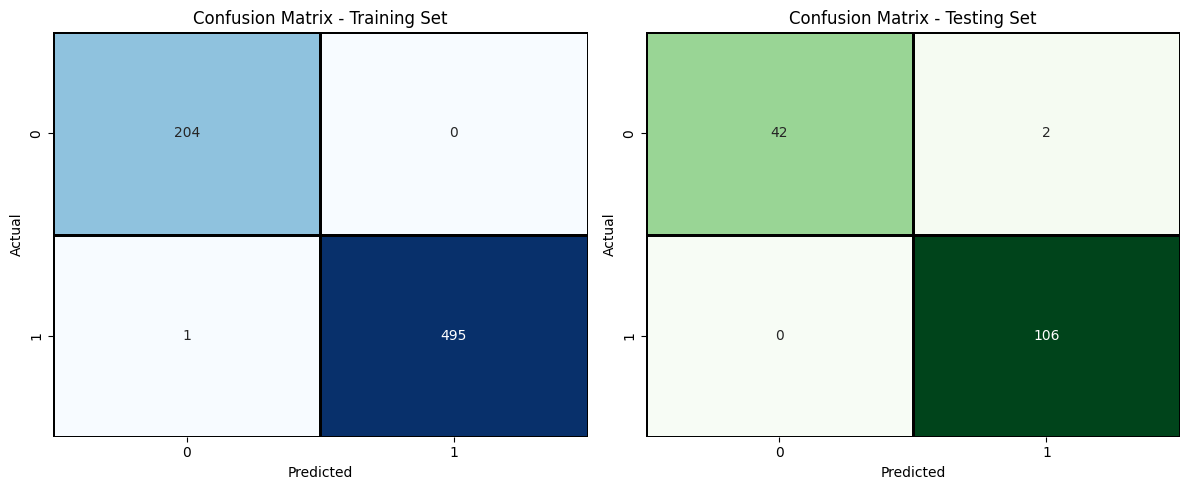

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrices
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Training CM
sns.heatmap(cm_train, annot=True, fmt='d', cmap="Blues",
            cbar=False, linewidths=1, linecolor='black', ax=axes[0])

axes[0].set_title("Confusion Matrix - Training Set")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Testing CM
sns.heatmap(cm_test, annot=True, fmt='d', cmap="Greens",
            cbar=False, linewidths=1, linecolor='black', ax=axes[1])

axes[1].set_title("Confusion Matrix - Testing Set")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=300)
plt.show()

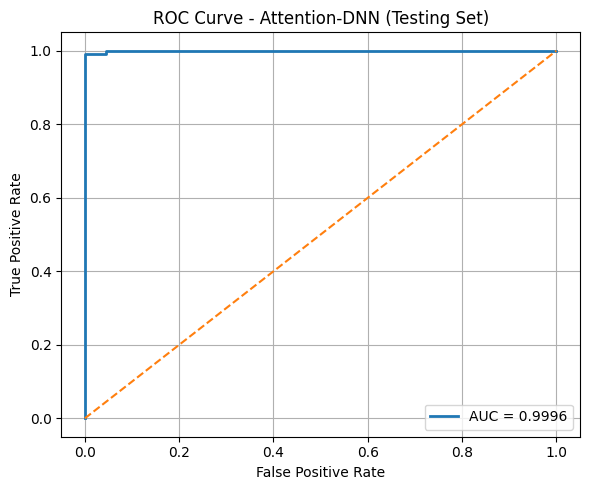

ROC-AUC Score: 0.9995711835334478


In [18]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Attention-DNN (Testing Set)")
plt.legend(loc="lower right")

plt.grid(True)

plt.tight_layout()
plt.savefig("roc_curve.png", dpi=300)
plt.show()

print("ROC-AUC Score:", roc_auc)

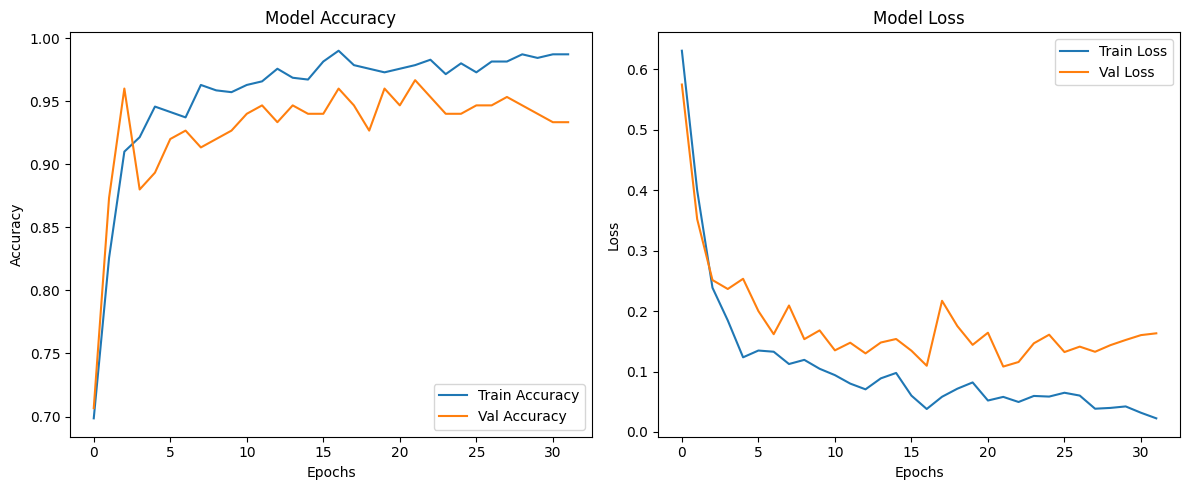

In [19]:
# Accuracy & Loss curves
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("training_history.png", dpi=300)
plt.show()

In [20]:
def save_figure(fig, filename, dpi=300):
    fig.savefig(f"{filename}.png", dpi=dpi, bbox_inches='tight')
    fig.savefig(f"{filename}.jpg", dpi=dpi, bbox_inches='tight')
    fig.savefig(f"{filename}.tiff", dpi=dpi, bbox_inches='tight')

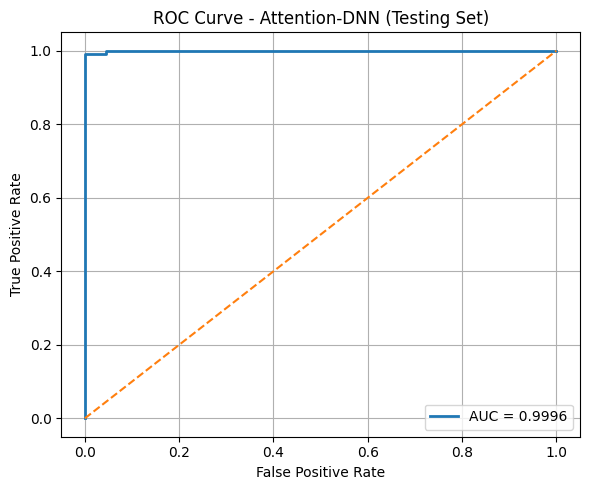

In [21]:
fig = plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Attention-DNN (Testing Set)")
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()

# Save in all formats
save_figure(fig, "roc_curve")

plt.show()

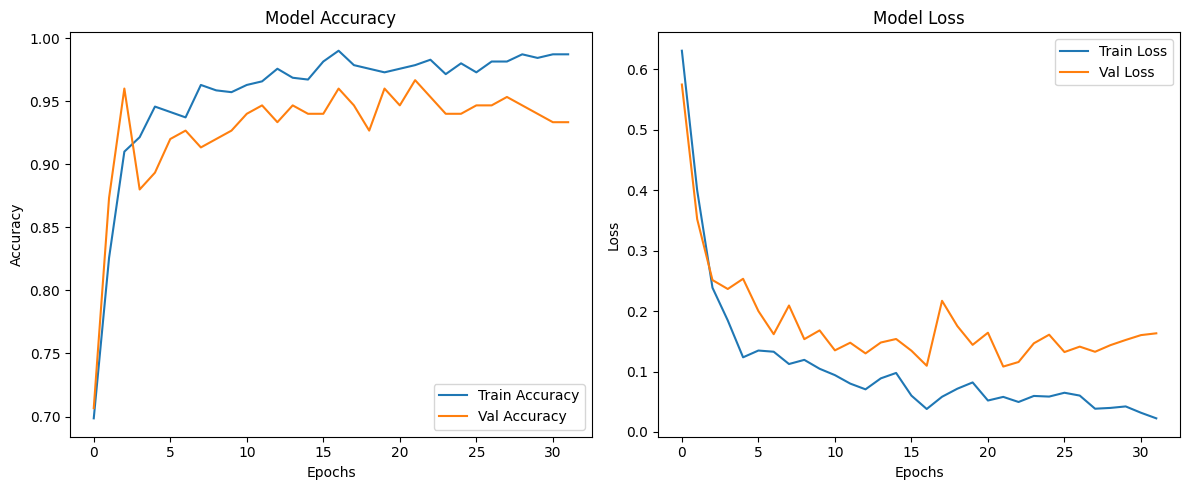

In [22]:
fig = plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()

# Save in all formats
save_figure(fig, "training_history")

plt.show()

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, auc

results = []

def save_figure(fig, filename, dpi=300):
    fig.savefig(f"{filename}.png", dpi=dpi, bbox_inches='tight')
    fig.savefig(f"{filename}.jpg", dpi=dpi, bbox_inches='tight')
    fig.savefig(f"{filename}.tiff", dpi=dpi, bbox_inches='tight')

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):

    # Metrics
    train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    # Predictions
    y_train_prob = model.predict(X_train)
    y_test_prob = model.predict(X_test)

    y_train_pred = (y_train_prob > 0.5).astype(int)
    y_test_pred = (y_test_prob > 0.5).astype(int)

    # Confusion matrices
    cm_train = confusion_matrix(y_train, y_train_pred)
    cm_test = confusion_matrix(y_test, y_test_pred)

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    roc_auc = auc(fpr, tpr)

    # Store results
    results.append({
        "Model": model_name,
        "Train Accuracy": train_acc,
        "Train Loss": train_loss,
        "Test Accuracy": test_acc,
        "Test Loss": test_loss,
        "AUC": roc_auc
    })

    # Plot confusion matrices
    fig, axes = plt.subplots(1,2, figsize=(12,5))

    sns.heatmap(cm_train, annot=True, fmt='d', cmap="Blues",
                ax=axes[0], cbar=False)
    axes[0].set_title(f"{model_name} - Train CM")

    sns.heatmap(cm_test, annot=True, fmt='d', cmap="Greens",
                ax=axes[1], cbar=False)
    axes[1].set_title(f"{model_name} - Test CM")

    plt.tight_layout()
    save_figure(fig, f"{model_name}_confusion_matrix")
    plt.close()

    return fpr, tpr, roc_auc

In [26]:
from tensorflow.keras import layers, models

def build_mlp(input_dim):
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

mlp = build_mlp(X_train.shape[1])
mlp.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)

fpr_mlp, tpr_mlp, auc_mlp = evaluate_model(mlp, X_train, y_train, X_test, y_test, "MLP")

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [27]:
def build_cnn(input_dim):
    inputs = layers.Input(shape=(input_dim,1))
    x = layers.Conv1D(32, 3, activation='relu')(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

X_train_cnn = X_train.reshape(-1, X_train.shape[1], 1)
X_test_cnn = X_test.reshape(-1, X_test.shape[1], 1)

cnn = build_cnn(X_train.shape[1])
cnn.fit(X_train_cnn, y_train, epochs=100, batch_size=32, verbose=0)

fpr_cnn, tpr_cnn, auc_cnn = evaluate_model(cnn, X_train_cnn, y_train, X_test_cnn, y_test, "CNN")

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [28]:
def build_autoencoder(input_dim):
    input_layer = layers.Input(shape=(input_dim,))
    encoded = layers.Dense(64, activation='relu')(input_layer)
    encoded = layers.Dense(32, activation='relu')(encoded)

    decoded = layers.Dense(64, activation='relu')(encoded)
    decoded = layers.Dense(input_dim)(decoded)

    autoencoder = models.Model(input_layer, decoded)
    encoder = models.Model(input_layer, encoded)

    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder

autoencoder, encoder = build_autoencoder(X_train.shape[1])
autoencoder.fit(X_train, X_train, epochs=50, batch_size=32, verbose=0)

X_train_enc = encoder.predict(X_train)
X_test_enc = encoder.predict(X_test)

clf = build_mlp(X_train_enc.shape[1])
clf.fit(X_train_enc, y_train, epochs=50, verbose=0)

fpr_ae, tpr_ae, auc_ae = evaluate_model(clf, X_train_enc, y_train, X_test_enc, y_test, "Autoencoder")

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [29]:
def build_residual(input_dim):
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(128, activation='relu')(inputs)

    shortcut = x
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(128)(x)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

res_model = build_residual(X_train.shape[1])
res_model.fit(X_train, y_train, epochs=50, verbose=0)

fpr_res, tpr_res, auc_res = evaluate_model(res_model, X_train, y_train, X_test, y_test, "Residual_DNN")

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [30]:
fpr_prop, tpr_prop, auc_prop = evaluate_model(
    model, X_train, y_train, X_test, y_test, "Attention_DNN"
)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


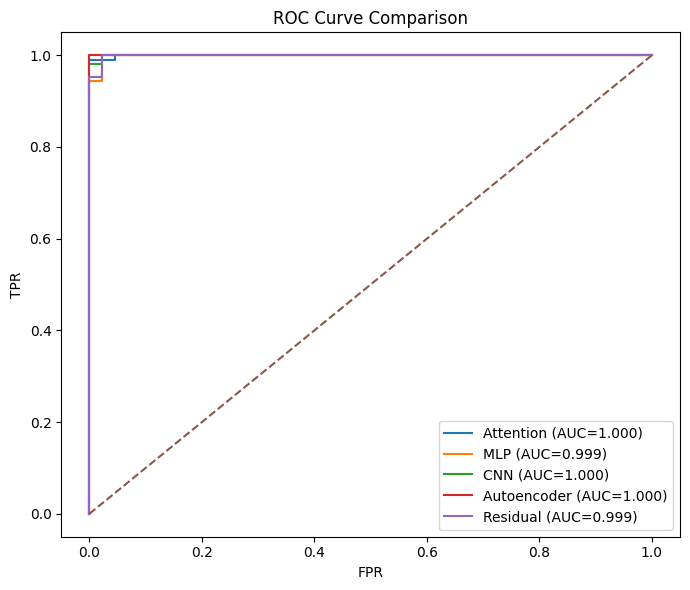

In [31]:
fig = plt.figure(figsize=(7,6))

plt.plot(fpr_prop, tpr_prop, label=f"Attention (AUC={auc_prop:.3f})")
plt.plot(fpr_mlp, tpr_mlp, label=f"MLP (AUC={auc_mlp:.3f})")
plt.plot(fpr_cnn, tpr_cnn, label=f"CNN (AUC={auc_cnn:.3f})")
plt.plot(fpr_ae, tpr_ae, label=f"Autoencoder (AUC={auc_ae:.3f})")
plt.plot(fpr_res, tpr_res, label=f"Residual (AUC={auc_res:.3f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve Comparison")
plt.legend()

plt.tight_layout()
save_figure(fig, "roc_comparison")
plt.show()

In [32]:
df_results = pd.DataFrame(results)

df_results.to_excel("model_comparison.xlsx", index=False)

print(df_results)

           Model  Train Accuracy  Train Loss  Test Accuracy  Test Loss  \
0            MLP        1.000000    0.000430       1.000000   0.006019   
1            CNN        1.000000    0.015056       0.986667   0.033132   
2            MLP        1.000000    0.000073       0.993333   0.046638   
3            CNN        1.000000    0.003177       0.980000   0.039132   
4    Autoencoder        0.998571    0.006317       1.000000   0.012737   
5   Residual_DNN        1.000000    0.000231       0.986667   0.048805   
6  Attention_DNN        0.998571    0.008566       0.986667   0.033287   

        AUC  
0  1.000000  
1  0.999571  
2  0.998714  
3  0.999571  
4  1.000000  
5  0.998928  
6  0.999571  


In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss

In [34]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):

    # Predictions
    y_train_prob = model.predict(X_train)
    y_test_prob = model.predict(X_test)

    y_train_pred = (y_train_prob > 0.5).astype(int)
    y_test_pred = (y_test_prob > 0.5).astype(int)

    # --- Metrics (TRAIN) ---
    train_acc = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    train_logloss = log_loss(y_train, y_train_prob)

    # --- Metrics (TEST) ---
    test_acc = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_logloss = log_loss(y_test, y_test_prob)

    # --- ROC ---
    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    roc_auc = auc(fpr, tpr)

    # --- Confusion Matrices ---
    cm_train = confusion_matrix(y_train, y_train_pred)
    cm_test = confusion_matrix(y_test, y_test_pred)

    # --- Store results ---
    results.append({
        "Model": model_name,

        "Train Accuracy": train_acc,
        "Train Precision": train_precision,
        "Train Recall": train_recall,
        "Train F1-score": train_f1,
        "Train Log Loss": train_logloss,

        "Test Accuracy": test_acc,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test F1-score": test_f1,
        "Test Log Loss": test_logloss,

        "AUC": roc_auc
    })

    # --- Plot Confusion Matrix ---
    fig, axes = plt.subplots(1,2, figsize=(12,5))

    sns.heatmap(cm_train, annot=True, fmt='d', cmap="Blues",
                ax=axes[0], cbar=False)
    axes[0].set_title(f"{model_name} - Train")

    sns.heatmap(cm_test, annot=True, fmt='d', cmap="Greens",
                ax=axes[1], cbar=False)
    axes[1].set_title(f"{model_name} - Test")

    plt.tight_layout()
    save_figure(fig, f"{model_name}_confusion_matrix")
    plt.close()

    return fpr, tpr, roc_auc

In [36]:
print(results)

[{'Model': 'MLP', 'Train Accuracy': 1.0, 'Train Loss': 0.00043015219853259623, 'Test Accuracy': 1.0, 'Test Loss': 0.006018809508532286, 'AUC': np.float64(1.0)}, {'Model': 'CNN', 'Train Accuracy': 1.0, 'Train Loss': 0.015056013129651546, 'Test Accuracy': 0.9866666793823242, 'Test Loss': 0.03313232213258743, 'AUC': np.float64(0.9995711835334478)}, {'Model': 'MLP', 'Train Accuracy': 1.0, 'Train Loss': 7.334285328397527e-05, 'Test Accuracy': 0.9933333396911621, 'Test Loss': 0.046638425439596176, 'AUC': np.float64(0.9987135506003431)}, {'Model': 'CNN', 'Train Accuracy': 1.0, 'Train Loss': 0.0031772926449775696, 'Test Accuracy': 0.9800000190734863, 'Test Loss': 0.039131585508584976, 'AUC': np.float64(0.9995711835334478)}, {'Model': 'Autoencoder', 'Train Accuracy': 0.9985714554786682, 'Train Loss': 0.006317156367003918, 'Test Accuracy': 1.0, 'Test Loss': 0.012736722826957703, 'AUC': np.float64(1.0)}, {'Model': 'Residual_DNN', 'Train Accuracy': 1.0, 'Train Loss': 0.0002314358134754002, 'Test A

In [35]:
df_results = pd.DataFrame(results)

# Round values for clean reporting
df_results = df_results.round(4)

df_results.to_excel("model_comparison.xlsx", index=False)

print(df_results)

           Model  Train Accuracy  Train Loss  Test Accuracy  Test Loss     AUC
0            MLP          1.0000      0.0004         1.0000     0.0060  1.0000
1            CNN          1.0000      0.0151         0.9867     0.0331  0.9996
2            MLP          1.0000      0.0001         0.9933     0.0466  0.9987
3            CNN          1.0000      0.0032         0.9800     0.0391  0.9996
4    Autoencoder          0.9986      0.0063         1.0000     0.0127  1.0000
5   Residual_DNN          1.0000      0.0002         0.9867     0.0488  0.9989
6  Attention_DNN          0.9986      0.0086         0.9867     0.0333  0.9996


In [37]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, log_loss, confusion_matrix,
    roc_curve, auc
)

import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
results = []
roc_data = {}

In [39]:
def save_figure(fig, filename, dpi=300):
    fig.savefig(f"{filename}.png", dpi=dpi, bbox_inches='tight')
    fig.savefig(f"{filename}.jpg", dpi=dpi, bbox_inches='tight')
    fig.savefig(f"{filename}.tiff", dpi=dpi, bbox_inches='tight')

In [40]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):

    # --- Predictions (FIXED SHAPE ISSUE) ---
    y_train_prob = model.predict(X_train).ravel()
    y_test_prob = model.predict(X_test).ravel()

    y_train_pred = (y_train_prob > 0.5).astype(int)
    y_test_pred = (y_test_prob > 0.5).astype(int)

    # --- TRAIN METRICS ---
    train_acc = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred, zero_division=0)
    train_recall = recall_score(y_train, y_train_pred, zero_division=0)
    train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
    train_logloss = log_loss(y_train, y_train_prob)

    # --- TEST METRICS ---
    test_acc = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
    test_logloss = log_loss(y_test, y_test_prob)

    # --- ROC ---
    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    roc_auc = auc(fpr, tpr)

    # Store ROC for comparison plot
    roc_data[model_name] = (fpr, tpr, roc_auc)

    # --- CONFUSION MATRICES ---
    cm_train = confusion_matrix(y_train, y_train_pred)
    cm_test = confusion_matrix(y_test, y_test_pred)

    # --- STORE RESULTS ---
    results.append({
        "Model": model_name,

        "Train Accuracy": train_acc,
        "Train Precision": train_precision,
        "Train Recall": train_recall,
        "Train F1-score": train_f1,
        "Train Log Loss": train_logloss,

        "Test Accuracy": test_acc,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test F1-score": test_f1,
        "Test Log Loss": test_logloss,

        "AUC": roc_auc
    })

    # --- CONFUSION MATRIX PLOT ---
    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    sns.heatmap(cm_train, annot=True, fmt='d', cmap="Blues",
                ax=axes[0], cbar=False)
    axes[0].set_title(f"{model_name} - Training")

    sns.heatmap(cm_test, annot=True, fmt='d', cmap="Greens",
                ax=axes[1], cbar=False)
    axes[1].set_title(f"{model_name} - Testing")

    plt.tight_layout()
    save_figure(fig, f"{model_name}_confusion_matrix")
    plt.close()

    print(f"{model_name} evaluation completed.")

In [41]:
# IMPORTANT: call for ALL models

evaluate_model(model, X_train, y_train, X_test, y_test, "Attention_DNN")
evaluate_model(mlp, X_train, y_train, X_test, y_test, "MLP")
evaluate_model(cnn, X_train_cnn, y_train, X_test_cnn, y_test, "CNN")
evaluate_model(clf, X_train_enc, y_train, X_test_enc, y_test, "Autoencoder")
evaluate_model(res_model, X_train, y_train, X_test, y_test, "Residual_DNN")

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Attention_DNN evaluation completed.
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
MLP evaluation completed.
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
CNN evaluation completed.
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Autoencoder evaluation completed.
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Residual_DNN evaluation completed.


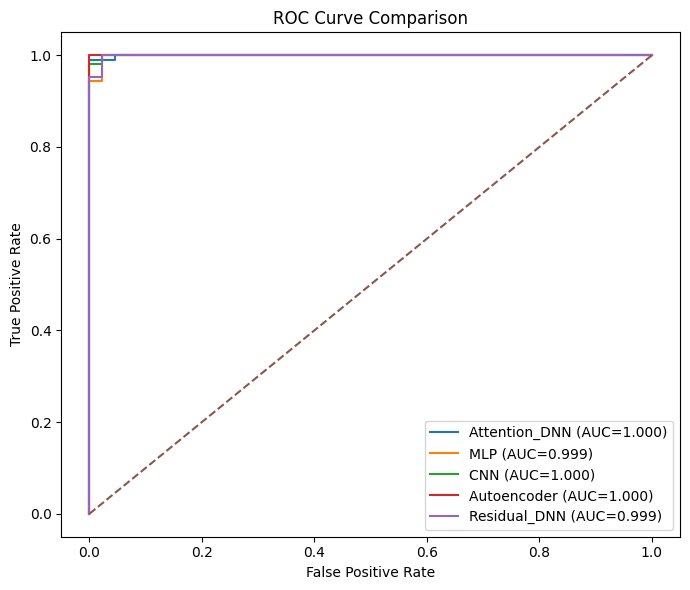

In [42]:
fig = plt.figure(figsize=(7,6))

for model_name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.tight_layout()
save_figure(fig, "roc_comparison")
plt.show()

In [43]:
df_results = pd.DataFrame(results)

# Clean formatting
df_results = df_results.round(4)

# Save Excel
df_results.to_excel("model_comparison.xlsx", index=False)

print("\nFinal Results Table:\n")
print(df_results)


Final Results Table:

           Model  Train Accuracy  Train Precision  Train Recall  \
0  Attention_DNN          0.9986              1.0         0.998   
1            MLP          1.0000              1.0         1.000   
2            CNN          1.0000              1.0         1.000   
3    Autoencoder          0.9986              1.0         0.998   
4   Residual_DNN          1.0000              1.0         1.000   

   Train F1-score  Train Log Loss  Test Accuracy  Test Precision  Test Recall  \
0           0.999          0.0086         0.9867          0.9815       1.0000   
1           1.000          0.0001         0.9933          0.9907       1.0000   
2           1.000          0.0032         0.9800          0.9905       0.9811   
3           0.999          0.0063         1.0000          1.0000       1.0000   
4           1.000          0.0002         0.9867          0.9906       0.9906   

   Test F1-score  Test Log Loss     AUC  
0         0.9907         0.0333  0.9996  
1  

In [44]:
import zipfile
import os

zip_filename = "model_results_images.zip"

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in os.listdir():
        if file.endswith((".png", ".jpg", ".tiff")):
            zipf.write(file)

print("ZIP file created successfully.")

ZIP file created successfully.


In [45]:
from google.colab import files

files.download("model_results_images.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>